# Bank Customer Churn Analysis (Churn Modelling)

---

## 1. Problem Definition

Customer churn represents one of the major challenges faced by banking institutions. When a customer leaves the bank, it results in a direct loss of revenue and often high costs to acquire new customers.

**Main problem:** Identify the factors that influence a customer's decision to leave the bank, and predict the future behavior of customers.

**Analysis objective:** Understand the demographic, financial, and behavioral characteristics of customers who left the bank (*Exited = 1*) compared to those who stayed (*Exited = 0*).

---

## 2. Column Descriptions

| Column Name | Meaning | Role in analysis |
|---|---|---|
| RowNumber | Row number (sequential identifier) | Ignored (non-informative) |
| CustomerId | Unique customer identifier | Ignored (non-informative) |
| Surname | Customer's last name | Ignored (non-informative) |
| CreditScore | Customer's credit score | Numerical explanatory variable |
| Geography | Customer's country of residence | Categorical explanatory variable |
| Gender | Customer's gender | Categorical explanatory variable |
| Age | Customer's age in years | Numerical explanatory variable |
| Tenure | Number of years with the bank | Numerical explanatory variable |
| Balance | Bank account balance | Numerical explanatory variable |
| NumOfProducts | Number of banking products subscribed | Numerical explanatory variable |
| HasCrCard | Has a credit card (1=Yes, 0=No) | Binary explanatory variable |
| IsActiveMember | Active member (1=Yes, 0=No) | Binary explanatory variable |
| EstimatedSalary | Estimated customer salary (in â‚¬) | Target variable for regression |
| Exited | Left the bank (1=Yes, 0=No) | Target variable for classification |

---

# Part 1 : Data Understanding

### Importing Libraries

We import all necessary libraries for data analysis, visualization, and modeling.

In [737]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_curve, auc



### Loading the Dataset

We load the CSV file into a pandas DataFrame. This step is the first interaction with the raw data.

In [738]:
df = pd.read_csv("Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


### Dataset Dimensions and Size

We display the number of rows and columns (`shape`) as well as the total number of elements (`size`) to get an initial idea of the dataset's scale.

In [739]:
df.shape

(10000, 14)

In [740]:
df.size

140000

### Preview of First and Last Rows

We display the first and last rows of the DataFrame to get a visual overview of the data and verify its consistency.

In [741]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [742]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


### Column Names and Data Types

We list all column names (`columns`) and their respective data types (`dtypes`) to identify numerical and categorical variables.

In [743]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [744]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

### General DataFrame Information

The `info()` method provides a concise summary including the number of non-null values per column, allowing us to quickly detect columns with missing values.

In [745]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


### Detecting Duplicates and Missing Values

We check the number of duplicated rows and the number of missing values per column, along with their percentage relative to the total dataset size.

In [746]:
df.duplicated().sum()

np.int64(0)

In [747]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

### Descriptive Statistics â€” Numerical Variables

The `describe()` method computes basic statistics (mean, standard deviation, min, max, quartiles) for all numerical columns.

In [748]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


### Descriptive Statistics â€” Categorical Variables

We use `describe(include='object')` to analyze text-type columns, displaying the number of unique values and the most frequent value.

In [749]:
df.describe(include='object')

,Surname,Geography,Gender
count,10000,10000,10000
unique,2932,3,2
top,Smith,France,Male
freq,32,5014,5457


### Distribution of Categorical Variables

We display the count of each category for categorical columns to understand the distribution of categories in the dataset.

In [750]:
for col in df.select_dtypes(include="object").columns:
    display(df[col].value_counts())

Surname
Smith        32
Scott        29
Martin       29
Walker       28
Brown        26
             ..
Salinas       1
Cleveland     1
Kashiwagi     1
Aldridge      1
Burbidge      1
Name: count, Length: 2932, dtype: int64

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender
Male      5457
Female    4543
Name: count, dtype: int64

### Number of Unique Values per Column

We examine the number of distinct values per column (`nunique()`), which helps distinguish continuous variables from discrete or categorical ones.

In [751]:
df.nunique()

RowNumber          10000
CustomerId         10000
Surname             2932
CreditScore          460
Geography              3
Gender                 2
Age                   70
Tenure                11
Balance             6382
NumOfProducts          4
HasCrCard              2
IsActiveMember         2
EstimatedSalary     9999
Exited                 2
dtype: int64

### Correlation Matrix

We compute and display the correlation matrix for numerical columns to identify linear relationships between variables.

In [752]:
import plotly.express as px
# 1. Select only numeric columns (correlation cannot be computed on text)
df_numeric = df.select_dtypes(include=['float64', 'int64', 'int32'])

# 2. Compute the correlation matrix
corr_matrix = df_numeric.corr()

# 3. Display the heatmap with Plotly
fig = px.imshow(corr_matrix,
                text_auto='.2f',
                aspect="auto",
                color_continuous_scale='RdBu_r',
                title="Correlation Heatmap between Variables")

fig.update_layout(
    width=800,
    height=700,
    template="plotly_dark"
)

fig.show()

---

# Part 2 : Data Cleaning
    1. Missing values
    2. Duplicate rows 
    3. Outliers

## 2.1 Handling Missing Values

In [753]:
df['CreditScore'].isnull().sum()

np.int64(0)

## 2.3 Removing Duplicates

We first check if duplicates exist, then remove them to ensure each record is unique.

In [754]:
df.duplicated().sum()

np.int64(0)

## 2.4 Detecting and Handling Outliers

### Outlier Visualization  Box Plots

We plot a box plot (*boxplot*) for each numerical variable to visualize the distribution and detect extreme values.

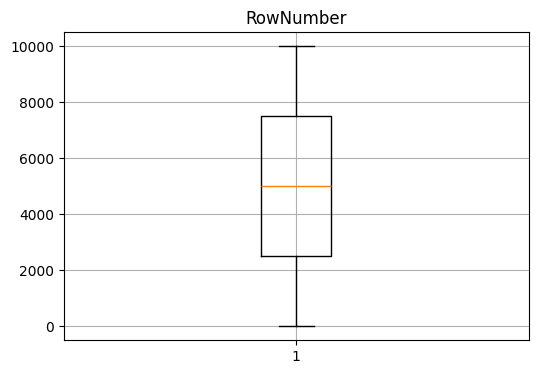

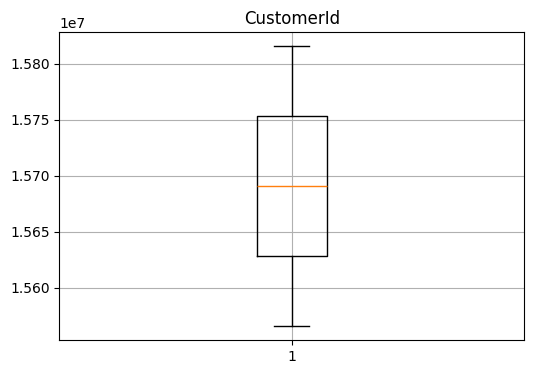

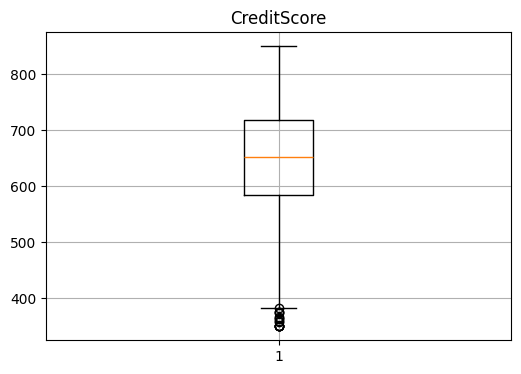

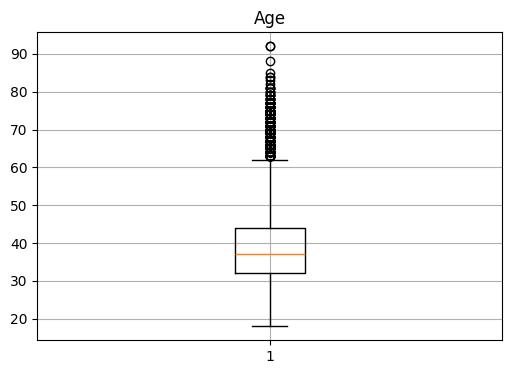

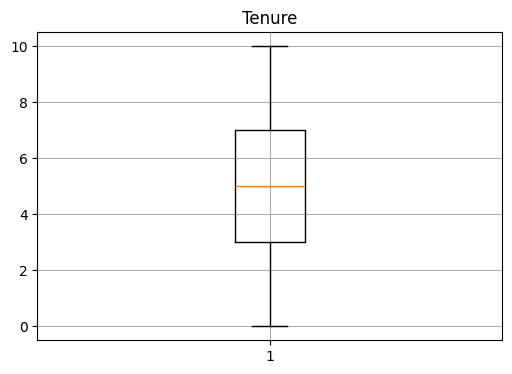

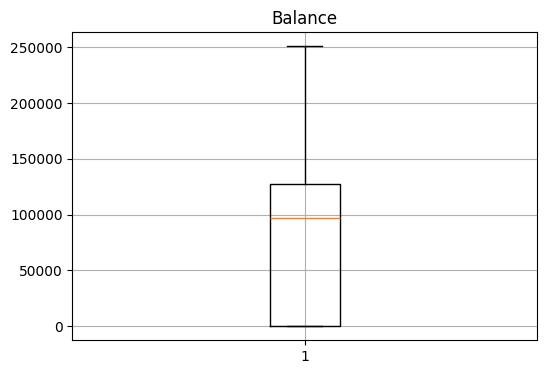

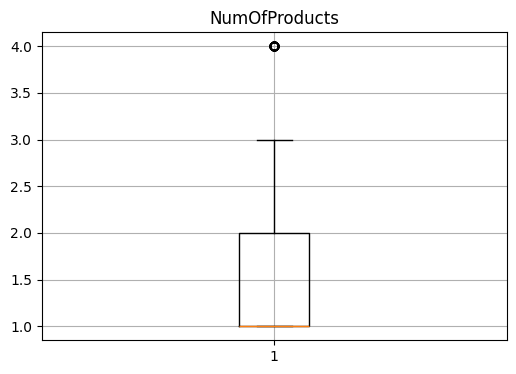

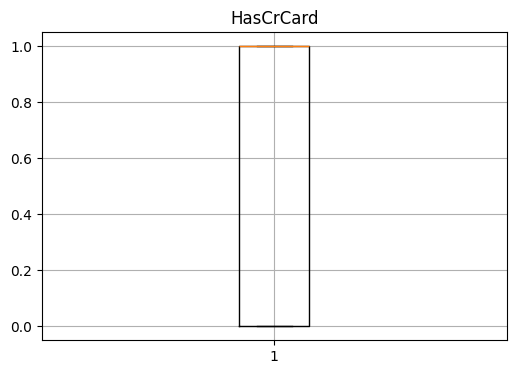

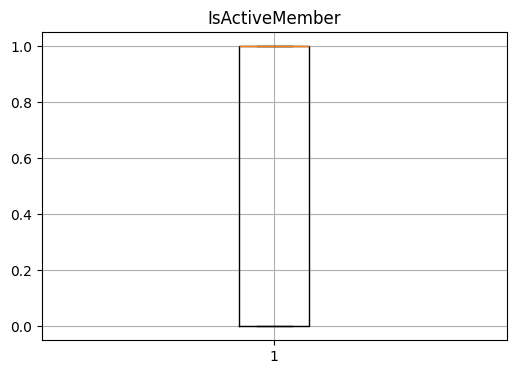

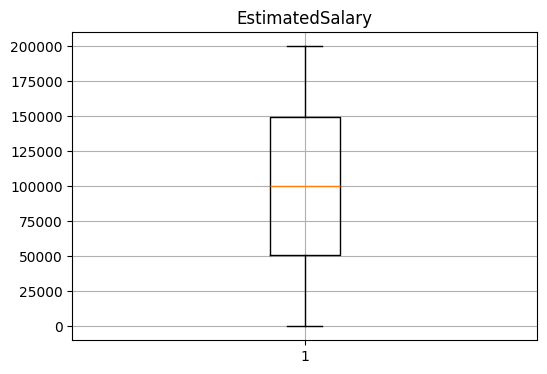

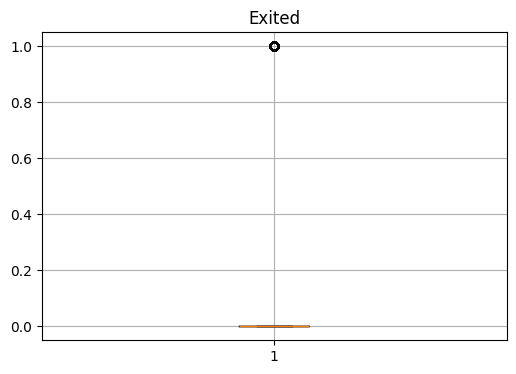

In [755]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col])
    plt.title(col)
    plt.grid()
    plt.show()

### Outlier Visualization  Scatter Plots

We plot a scatter plot for each numerical variable with the index on the x-axis to spot isolated values and overall trends.

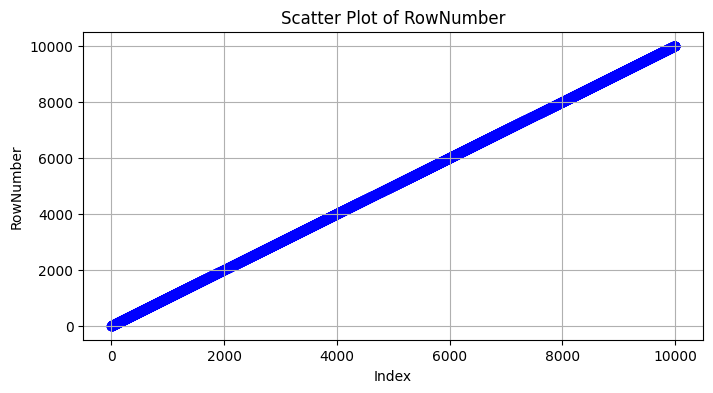

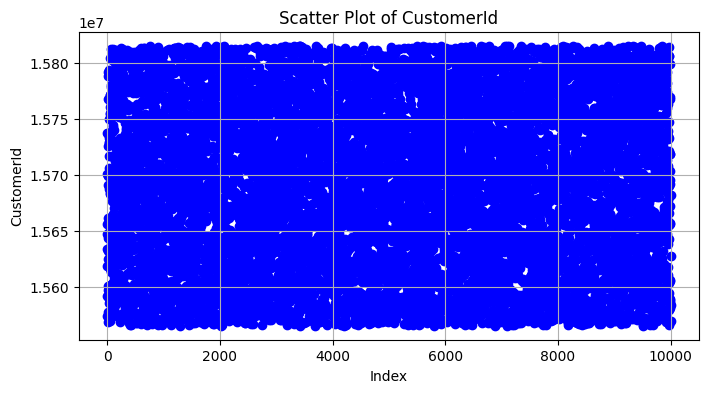

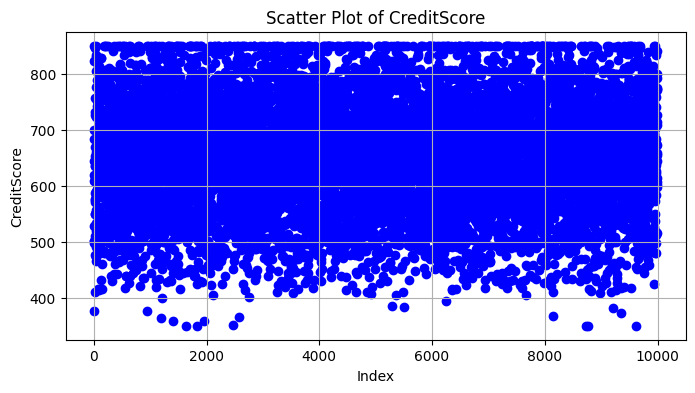

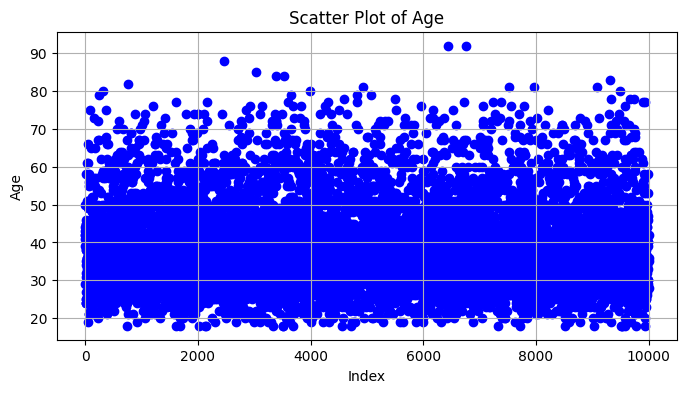

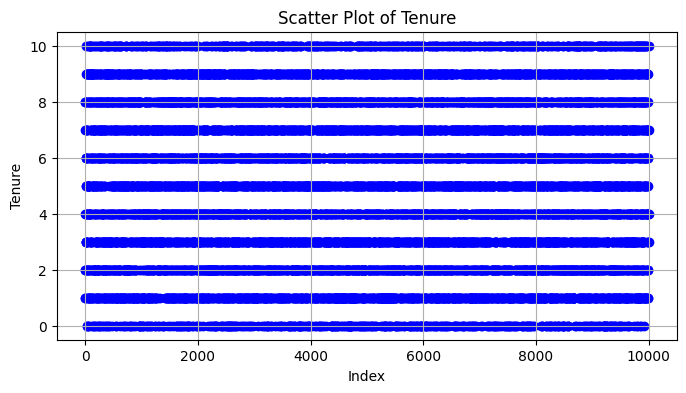

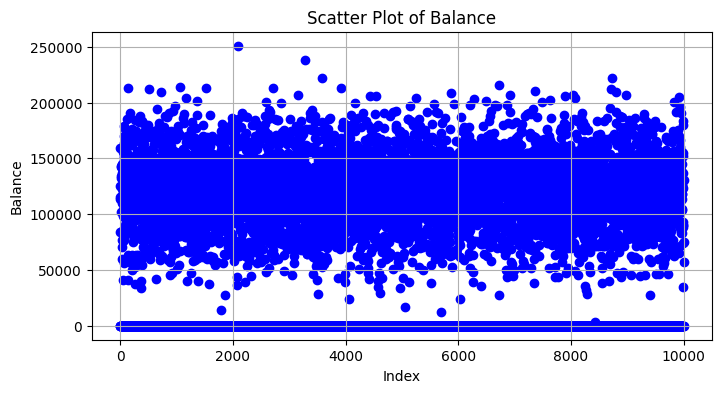

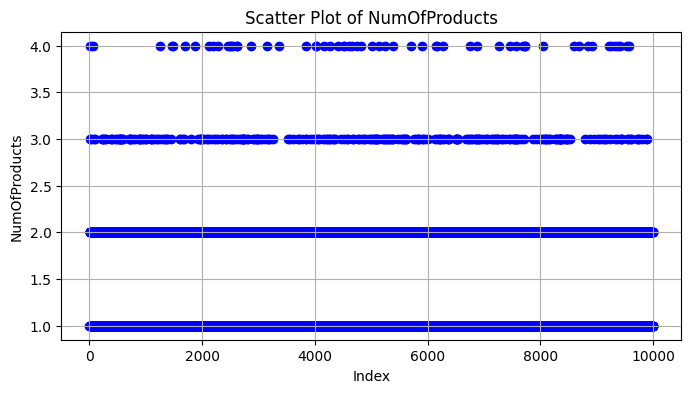

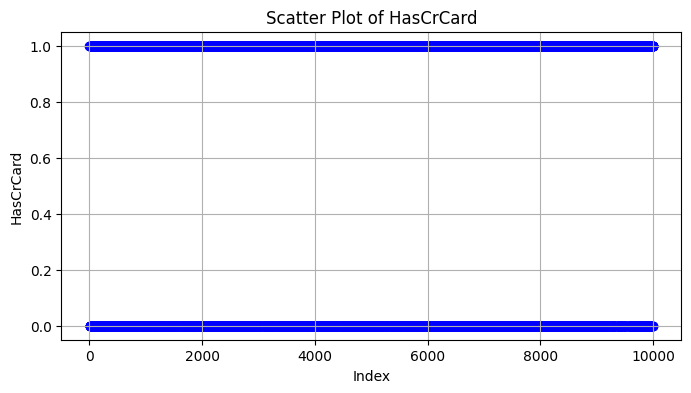

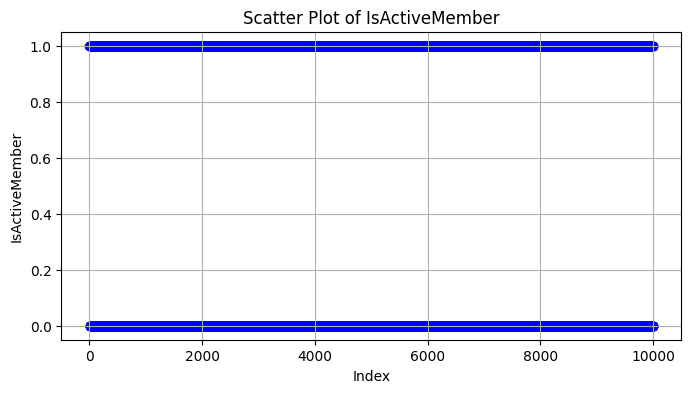

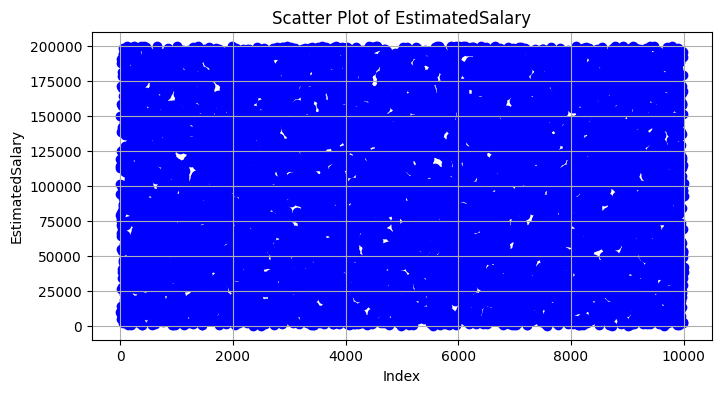

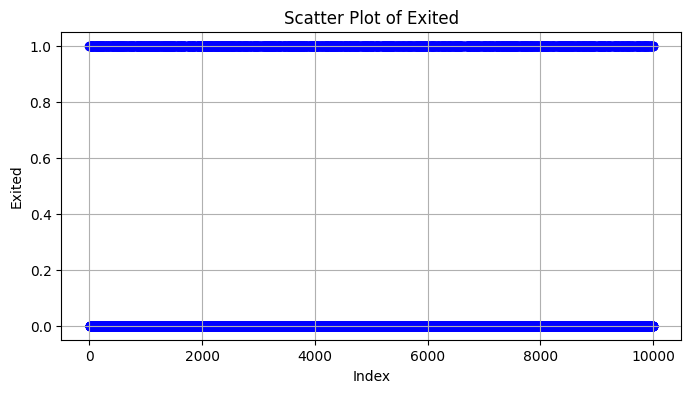

In [756]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.scatter(range(len(df)), df[col], color='blue', edgecolor='blue')
    plt.title(f'Scatter Plot of {col}')
    plt.xlabel('Index')
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

### Outlier Detection  Z-Score Method

We apply the Z-score method to identify values whose distance from the mean exceeds 3 standard deviations (|z| > 3) for each numerical column.

In [757]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    outliers = df[z_scores > 3][col]
    print(f"{col} outliers Count:", outliers.shape[0])

RowNumber outliers Count: 0
CustomerId outliers Count: 0
CreditScore outliers Count: 8
Age outliers Count: 133
Tenure outliers Count: 0
Balance outliers Count: 0
NumOfProducts outliers Count: 60
HasCrCard outliers Count: 0
IsActiveMember outliers Count: 0
EstimatedSalary outliers Count: 0
Exited outliers Count: 0


### Outlier Detection  IQR Method

We apply the interquartile range (IQR) method to identify values outside the bounds [Q1 - 1.5Ã—IQR, Q3 + 1.5Ã—IQR] for each numerical column.

In [758]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    print(f"{col} outliers Count:", outliers.shape[0])

RowNumber outliers Count: 0
CustomerId outliers Count: 0
CreditScore outliers Count: 15
Age outliers Count: 359
Tenure outliers Count: 0
Balance outliers Count: 0
NumOfProducts outliers Count: 60
HasCrCard outliers Count: 0
IsActiveMember outliers Count: 0
EstimatedSalary outliers Count: 0
Exited outliers Count: 2037


---

# Part 3 : Data Preprocessing
    -1. Encode categorical features
    -2. Scale numeric features

In [759]:
df = df.drop(['RowNumber', 'Surname', 'CustomerId'], axis=1)

In [760]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


### 1. Encode categorical features

In [761]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [762]:
# one hot encoding
df_encoded=pd.get_dummies(df,columns=['Geography'],dtype=int)
df_encoded

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,Female,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,Female,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,Female,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,Female,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,Female,43,2,125510.82,1,1,1,79084.10,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,Male,39,5,0.00,2,1,0,96270.64,0,1,0,0
9996,516,Male,35,10,57369.61,1,1,1,101699.77,0,1,0,0
9997,709,Female,36,7,0.00,1,0,1,42085.58,1,1,0,0
9998,772,Male,42,3,75075.31,2,1,0,92888.52,1,0,1,0


In [763]:
# Initialize the encoder
le = LabelEncoder()

# Apply label encoding to the 'Gender' column
df_encoded['Gender'] = le.fit_transform(df_encoded['Gender'])
df_encoded.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1,0,0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,0,1
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1,0,0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,0,1


### 3. Feature Engineering  Adding Meaningful Interaction Features

We create three new features that capture patterns consistently observed in churn analysis:
- **IsZeroBalance**: customers with zero balance churn at a different rate than those with savings
- **Balance_Salary_Ratio**: balance relative to salary captures financial "health" more meaningfully than balance alone
- **Age_Activity**: interaction between age and active-member status  older inactive customers churn most

In [764]:
df_encoded['IsZeroBalance'] = (df_encoded['Balance'] == 0).astype(int)
df_encoded['Balance_Salary_Ratio'] = df_encoded['Balance'] / (df_encoded['EstimatedSalary'] + 1)
df_encoded['Age_Activity'] = df_encoded['Age'] * df_encoded['IsActiveMember']

df_encoded[['IsZeroBalance', 'Balance_Salary_Ratio', 'Age_Activity']].head()

,IsZeroBalance,Balance_Salary_Ratio,Age_Activity
0,1,0.000000,42
1,0,0.744670,41
2,0,1.401362,0
3,1,0.000000,0
4,0,1.587035,43


### 2. Scale Numeric Variables â€” StandardScaler

**Problem:** Columns have very different scales:
- `Age`: 18 â†’ 92
- `Balance`: 0 â†’ 250,000
- `EstimatedSalary`: 11 â†’ 199,992

The model risks giving more importance to large values, which **skews the results**.

**Solution â€” StandardScaler:** brings each column around **0** with a standard deviation of **1**:

$$z = \frac{x - \mu}{\sigma}$$

**Important rule:**
- `fit_transform` â†’ on **Train only** (learns the mean and standard deviation)
- `transform` â†’ on **Test only** (applies without relearning â€” otherwise we cheat)

In [765]:
# X & y
X=df_encoded.drop('Exited',axis=1)
y= df_encoded['Exited']

# split train & test
X_train, X_test , y_train, y_test =train_test_split(X,y,test_size=0.2,random_state=42)

In [766]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [767]:
X_train

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,IsZeroBalance,Balance_Salary_Ratio,Age_Activity
9254,686,1,32,6,0.00,2,1,1,179093.26,1,0,0,1,0.000000,32
1561,632,1,42,4,119624.60,2,1,1,195978.86,0,1,0,0,0.610392,42
1670,559,1,24,3,114739.92,1,1,0,85891.02,0,0,1,0,1.335862,0
6087,561,0,27,9,135637.00,1,1,0,153080.40,1,0,0,0,0.886045,0
6669,517,1,56,9,142147.32,1,0,0,39488.04,1,0,0,0,3.599665,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,768,1,54,8,69712.74,1,1,1,69381.05,1,0,0,0,1.004766,54
5191,682,0,58,1,0.00,1,1,1,706.50,1,0,0,1,0.000000,58
5390,735,0,38,1,0.00,3,0,0,92220.12,1,0,0,1,0.000000,0
860,667,1,43,8,190227.46,1,1,0,97508.04,1,0,0,0,1.950870,0


In [768]:
y_train

9254    0
1561    0
1670    1
6087    1
6669    1
       ..
5734    0
5191    0
5390    1
860     1
7270    0
Name: Exited, Length: 8000, dtype: int64

In [769]:
# X encoded (remaining numeric columns) and y
X_encoded = df_encoded.drop('Exited', axis=1)
y = df_encoded['Exited']

# Check column types (int64 or float64)
print(X_encoded.dtypes)  

# Apply SMOTE to get exactly equal class counts
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_encoded, y)

print("Before SMOTE:", y.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_resampled).value_counts().to_dict())

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)

# Scale after split
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

CreditScore               int64
Gender                    int64
Age                       int64
Tenure                    int64
Balance                 float64
NumOfProducts             int64
HasCrCard                 int64
IsActiveMember            int64
EstimatedSalary         float64
Geography_France          int64
Geography_Germany         int64
Geography_Spain           int64
IsZeroBalance             int64
Balance_Salary_Ratio    float64
Age_Activity              int64
dtype: object
Before SMOTE: {0: 7963, 1: 2037}
After SMOTE: {1: 7963, 0: 7963}


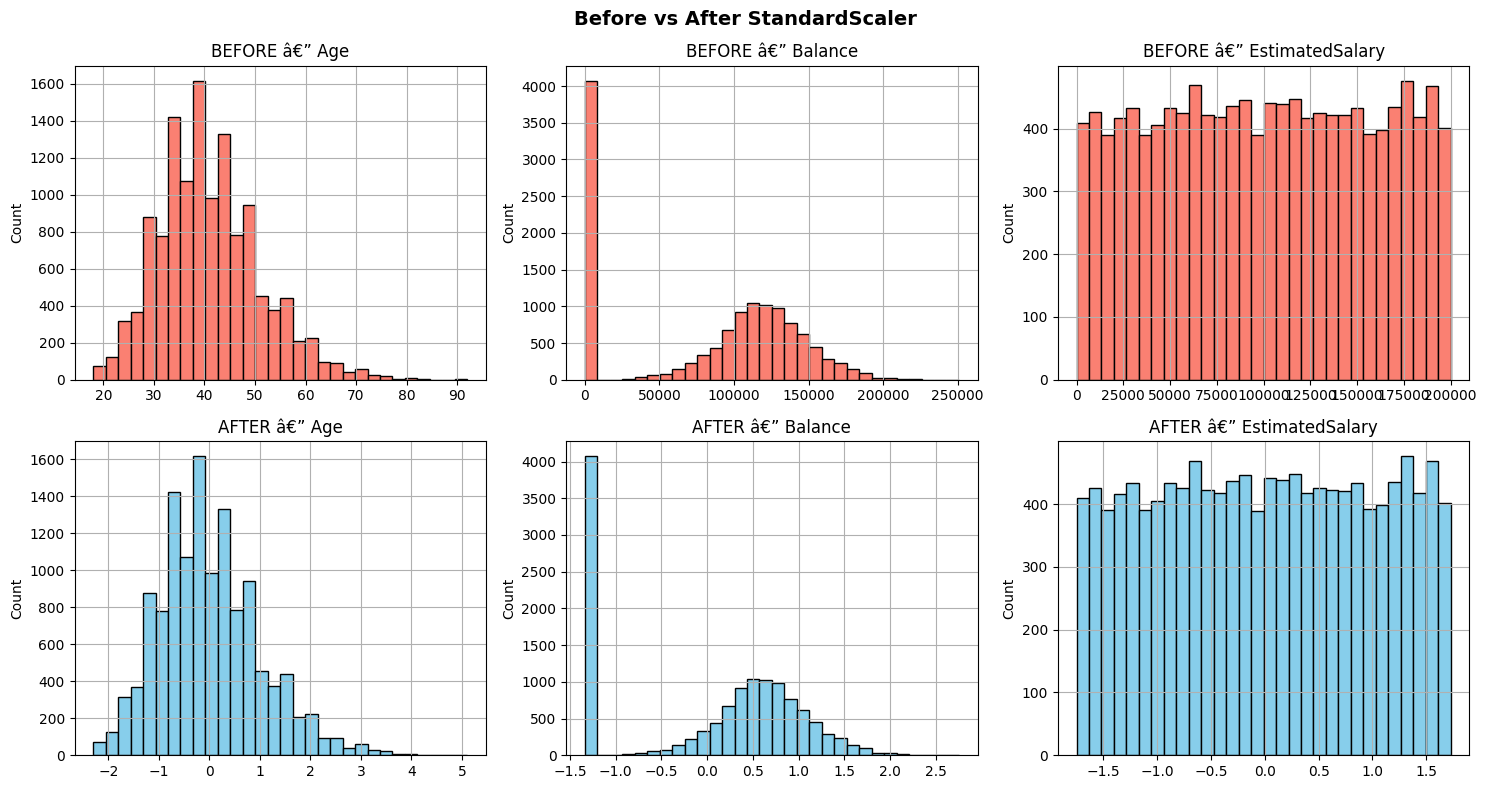

Statistics BEFORE scaling:
        Age    Balance  EstimatedSalary
mean  40.96   82029.59        100673.53
std   10.00   61394.35         57569.25
min   18.00       0.00            11.58
max   92.00  250898.09        199992.48

Statistics AFTER scaling:
       Age  Balance  EstimatedSalary
mean  0.00     0.00             0.00
std   1.00     1.00             1.00
min  -2.30    -1.34            -1.75
max   5.11     2.75             1.73


In [770]:
# Visualization Before / After StandardScaler on 3 key columns
cols_to_show = ['Age', 'Balance', 'EstimatedSalary']
col_indices = [list(X_encoded.columns).index(c) for c in cols_to_show]

X_train_df = pd.DataFrame(X_train_scaled, columns=X_encoded.columns)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Before vs After StandardScaler', fontsize=14, fontweight='bold')

for i, col in enumerate(cols_to_show):
    # Before
    axes[0, i].hist(X_train[col], bins=30, color='salmon', edgecolor='black')
    axes[0, i].set_title(f'BEFORE â€” {col}')
    axes[0, i].set_ylabel('Count')
    axes[0, i].grid(True)

    # After
    axes[1, i].hist(X_train_df[col], bins=30, color='skyblue', edgecolor='black')
    axes[1, i].set_title(f'AFTER â€” {col}')
    axes[1, i].set_ylabel('Count')
    axes[1, i].grid(True)

plt.tight_layout()
plt.show()

# Numerical summary
print("Statistics BEFORE scaling:")
print(X_train[cols_to_show].describe().loc[['mean', 'std', 'min', 'max']].round(2))
print("\nStatistics AFTER scaling:")
print(X_train_df[cols_to_show].describe().loc[['mean', 'std', 'min', 'max']].round(2))

---

# Part 4 : Data Analysis and Visualization

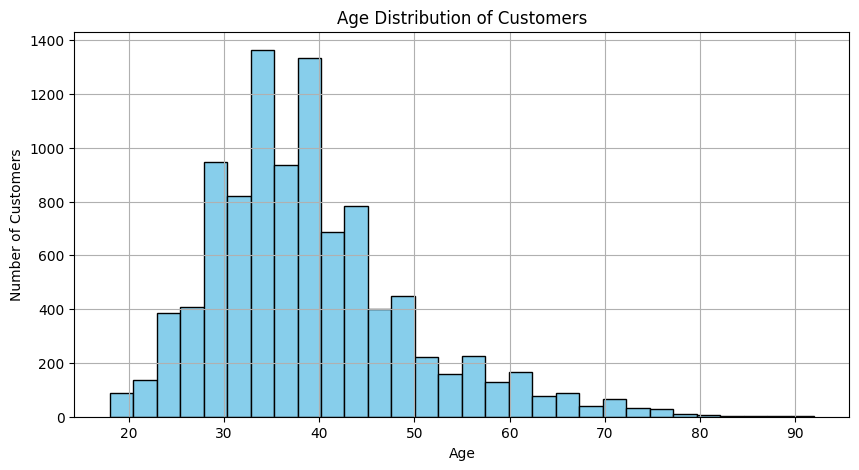

In [771]:
# 1. What is the age distribution of customers?
plt.figure(figsize=(10, 5))
plt.hist(df['Age'], bins=30, color='skyblue', edgecolor='black')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.grid()
plt.show()

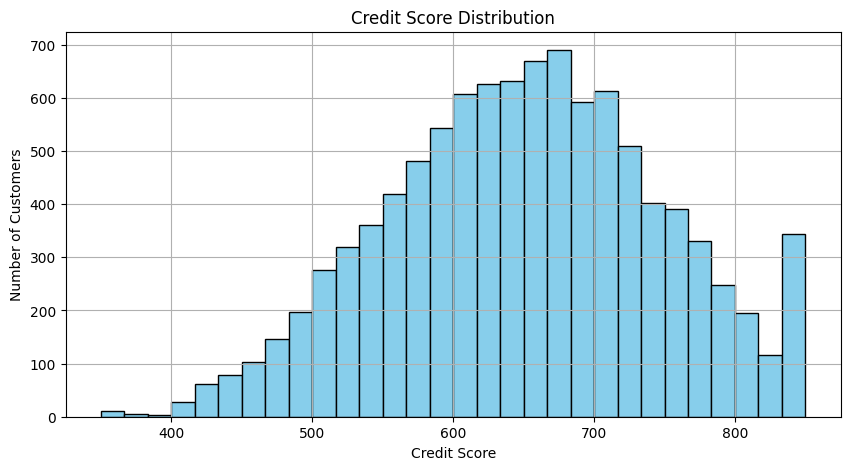

In [772]:
# 2. What is the distribution of customers' credit scores?
plt.figure(figsize=(10, 5))
plt.hist(df['CreditScore'], bins=30, color='skyblue', edgecolor='black')
plt.title('Credit Score Distribution')
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')
plt.grid()
plt.show()

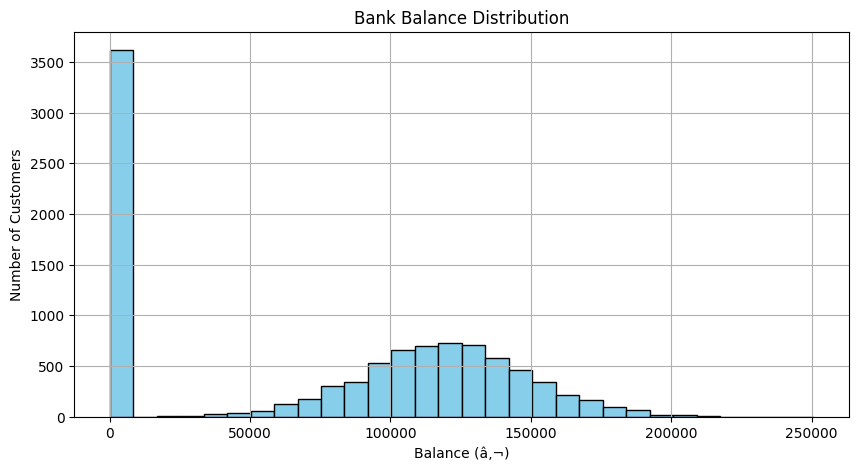

In [773]:
# 3. What is the distribution of customers' bank balances?
plt.figure(figsize=(10, 5))
plt.hist(df['Balance'], bins=30, color='skyblue', edgecolor='black')
plt.title('Bank Balance Distribution')
plt.xlabel('Balance (â‚¬)')
plt.ylabel('Number of Customers')
plt.grid()
plt.show()

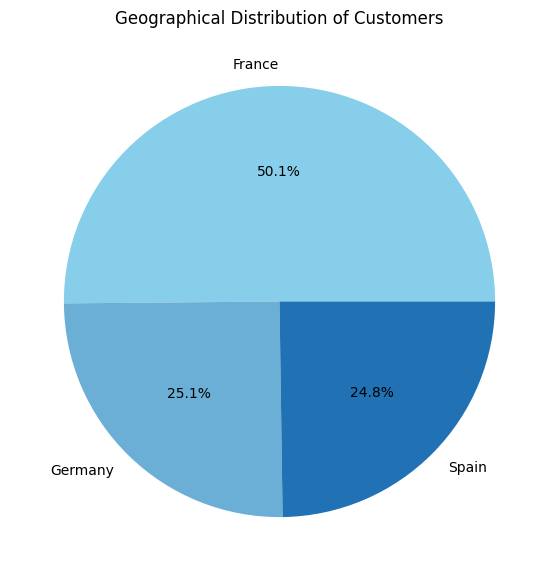

In [774]:
# 4. What is the geographical distribution of customers?
geo_counts = df['Geography'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(geo_counts, labels=geo_counts.index, autopct='%1.1f%%', colors=['skyblue', '#6baed6', '#2171b5'])
plt.title('Geographical Distribution of Customers')
plt.ylabel('')
plt.xlabel('')
plt.grid()
plt.show()

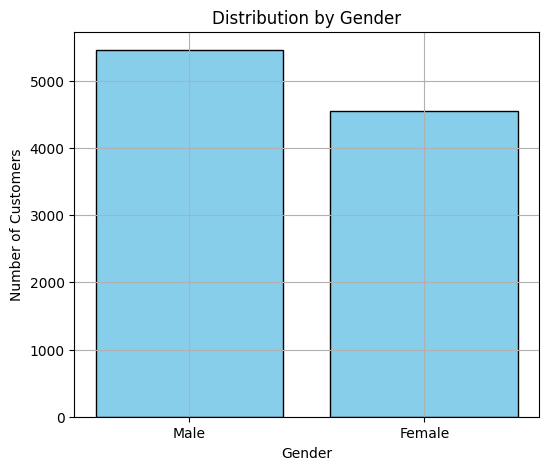

In [775]:
# 5. What is the male/female breakdown among customers?
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(6, 5))
plt.bar(gender_counts.index, gender_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.grid()
plt.show()

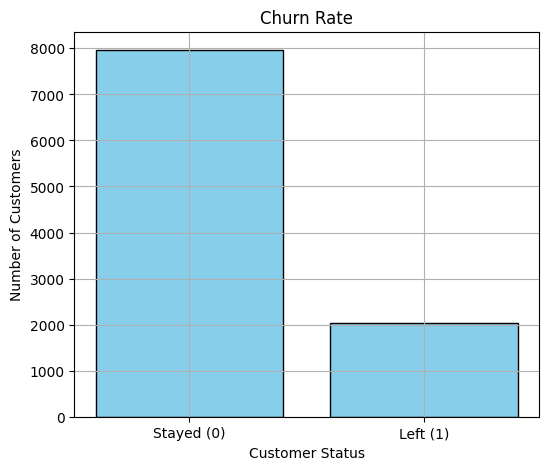

In [776]:
# 6. How many customers left the bank (Exited) vs those who stayed?
exited_counts = df['Exited'].value_counts()
plt.figure(figsize=(6, 5))
plt.bar(['Stayed (0)', 'Left (1)'], exited_counts.values, color='skyblue', edgecolor='black')
plt.title('Churn Rate')
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')
plt.grid()
plt.show()

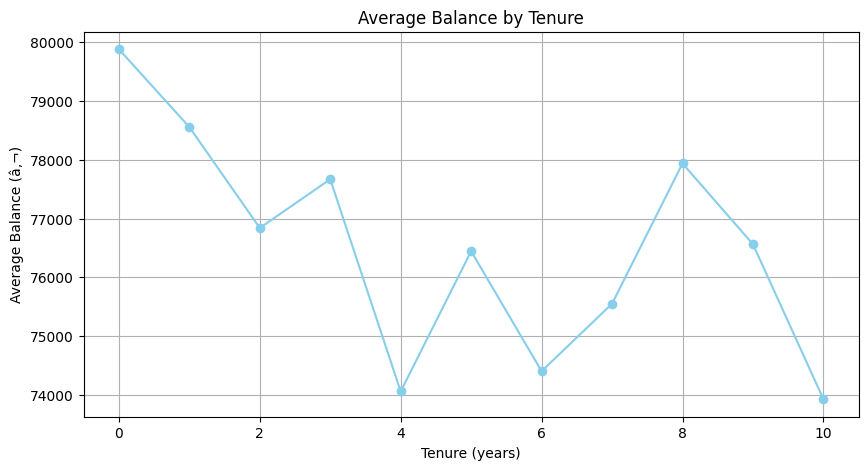

In [777]:
# 7. How does the average balance evolve with years of loyalty (Tenure)?
tenure_balance = df.groupby('Tenure')['Balance'].mean().reset_index()
plt.figure(figsize=(10, 5))
plt.plot(tenure_balance['Tenure'], tenure_balance['Balance'], color='skyblue', marker='o')
plt.title('Average Balance by Tenure')
plt.xlabel('Tenure (years)')
plt.ylabel('Average Balance (â‚¬)')
plt.grid()
plt.show()

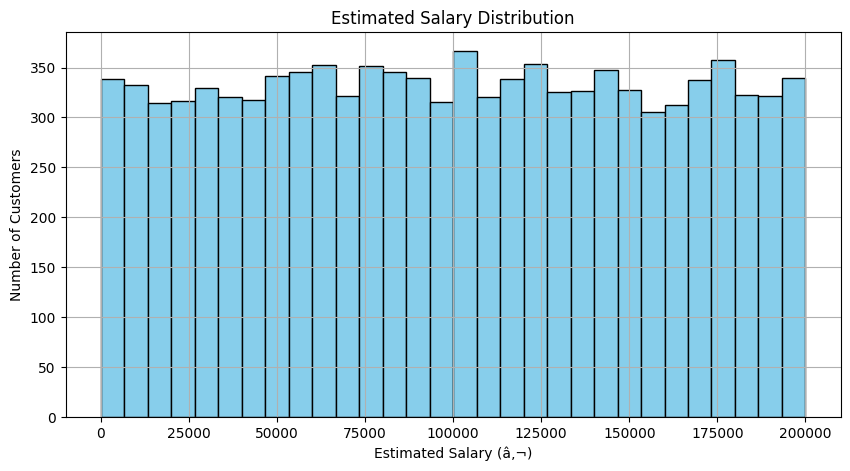

In [778]:
# 8. What is the distribution of customers' estimated salaries?
plt.figure(figsize=(10, 5))
plt.hist(df['EstimatedSalary'], bins=30, color='skyblue', edgecolor='black')
plt.title('Estimated Salary Distribution')
plt.xlabel('Estimated Salary (â‚¬)')
plt.ylabel('Number of Customers')
plt.grid()
plt.show()

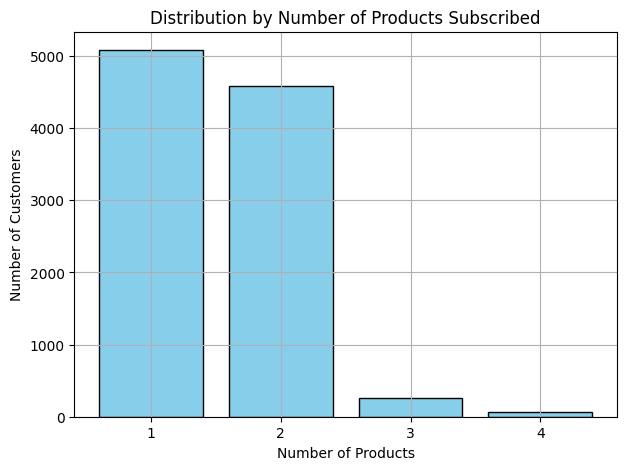

In [779]:
# 9. What is the distribution of customers by number of banking products subscribed?
prod_counts = df['NumOfProducts'].value_counts().sort_index()
plt.figure(figsize=(7, 5))
plt.bar(prod_counts.index.astype(str), prod_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribution by Number of Products Subscribed')
plt.xlabel('Number of Products')
plt.ylabel('Number of Customers')
plt.grid()
plt.show()

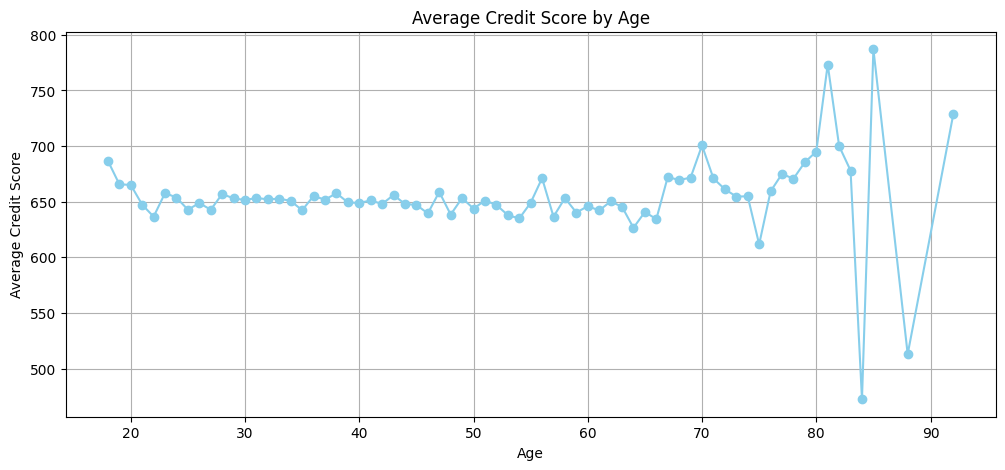

In [780]:
# 10. How does the average credit score evolve with customer age?
age_credit = df.groupby('Age')['CreditScore'].mean().reset_index()
plt.figure(figsize=(12, 5))
plt.plot(age_credit['Age'], age_credit['CreditScore'], color='skyblue', marker='o')
plt.title('Average Credit Score by Age')
plt.xlabel('Age')
plt.ylabel('Average Credit Score')
plt.grid()
plt.show()

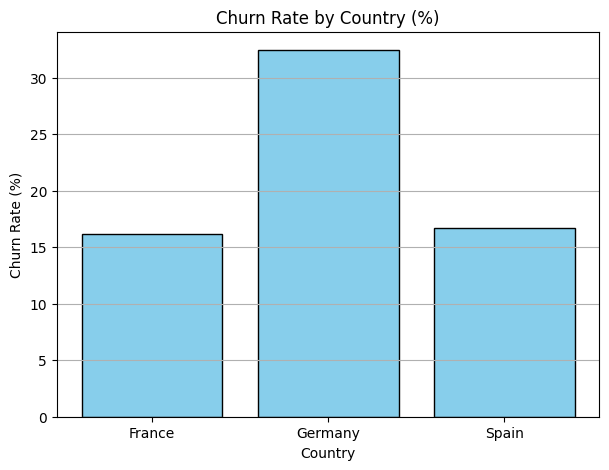

In [781]:
# Q11 â€” What is the churn rate by country?
churn_by_geo = df.groupby('Geography')['Exited'].mean() * 100

plt.figure(figsize=(7, 5))
plt.bar(churn_by_geo.index, churn_by_geo.values, color='skyblue', edgecolor='black')
plt.title('Churn Rate by Country (%)')
plt.xlabel('Country')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y')
plt.show()

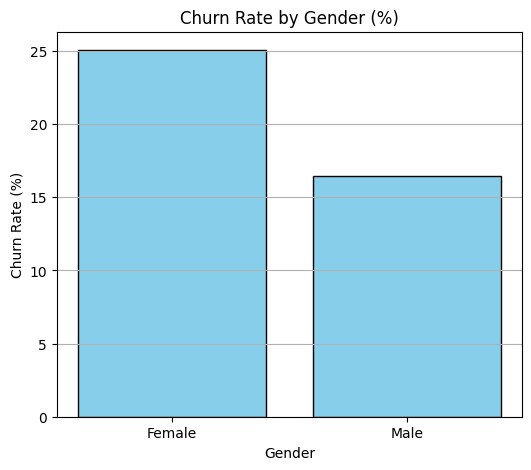

In [782]:
# Q12 â€” Do women have a higher churn rate than men?
churn_by_gender = df.groupby('Gender')['Exited'].mean() * 100

plt.figure(figsize=(6, 5))
plt.bar(churn_by_gender.index, churn_by_gender.values, color='skyblue', edgecolor='black')
plt.title('Churn Rate by Gender (%)')
plt.xlabel('Gender')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y')
plt.show()

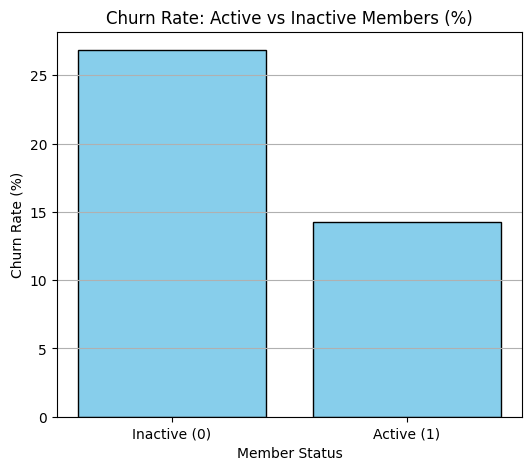

In [783]:
# Q13 â€” Do inactive customers leave more than active members?
churn_by_active = df.groupby('IsActiveMember')['Exited'].mean() * 100

plt.figure(figsize=(6, 5))
plt.bar(['Inactive (0)', 'Active (1)'], churn_by_active.values, color='skyblue', edgecolor='black')
plt.title('Churn Rate: Active vs Inactive Members (%)')
plt.xlabel('Member Status')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y')
plt.show()

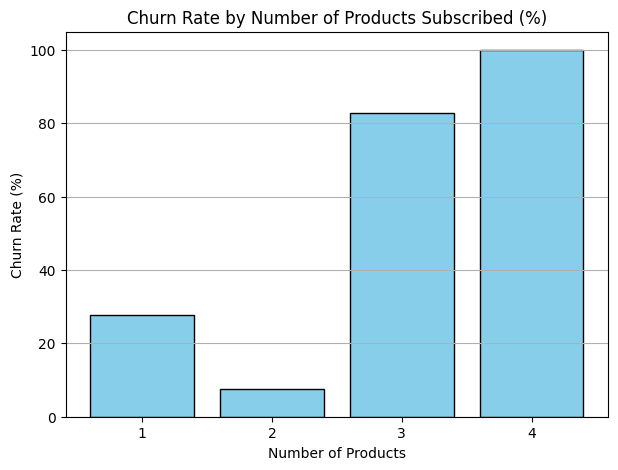

In [784]:
# Q14 â€” Is there a link between NumOfProducts and churn?
churn_by_prod = df.groupby('NumOfProducts')['Exited'].mean() * 100

plt.figure(figsize=(7, 5))
plt.bar(churn_by_prod.index.astype(str), churn_by_prod.values, color='skyblue', edgecolor='black')
plt.title('Churn Rate by Number of Products Subscribed (%)')
plt.xlabel('Number of Products')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y')
plt.show()

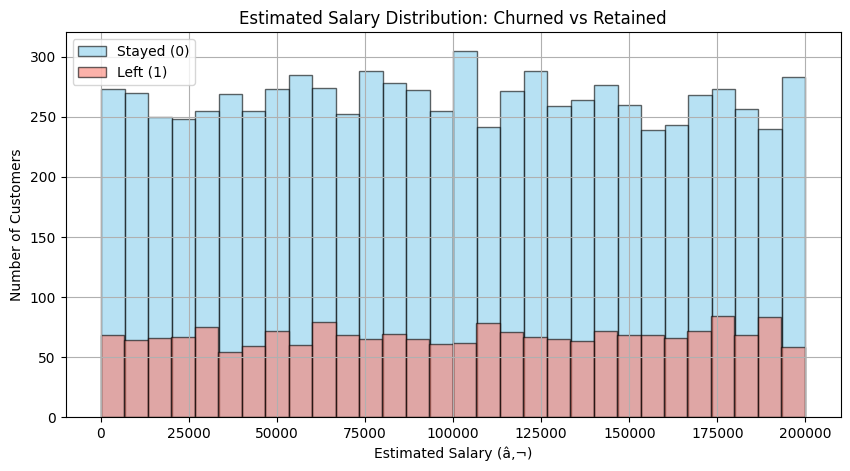

In [785]:
# Q17 â€” Is there a difference in estimated salary between churned and retained customers?
exited_0 = df[df['Exited'] == 0]['EstimatedSalary']
exited_1 = df[df['Exited'] == 1]['EstimatedSalary']

plt.figure(figsize=(10, 5))
plt.hist(exited_0, bins=30, alpha=0.6, color='skyblue', edgecolor='black', label='Stayed (0)')
plt.hist(exited_1, bins=30, alpha=0.6, color='salmon', edgecolor='black', label='Left (1)')
plt.title('Estimated Salary Distribution: Churned vs Retained')
plt.xlabel('Estimated Salary (â‚¬)')
plt.ylabel('Number of Customers')
plt.legend()
plt.grid()
plt.show()

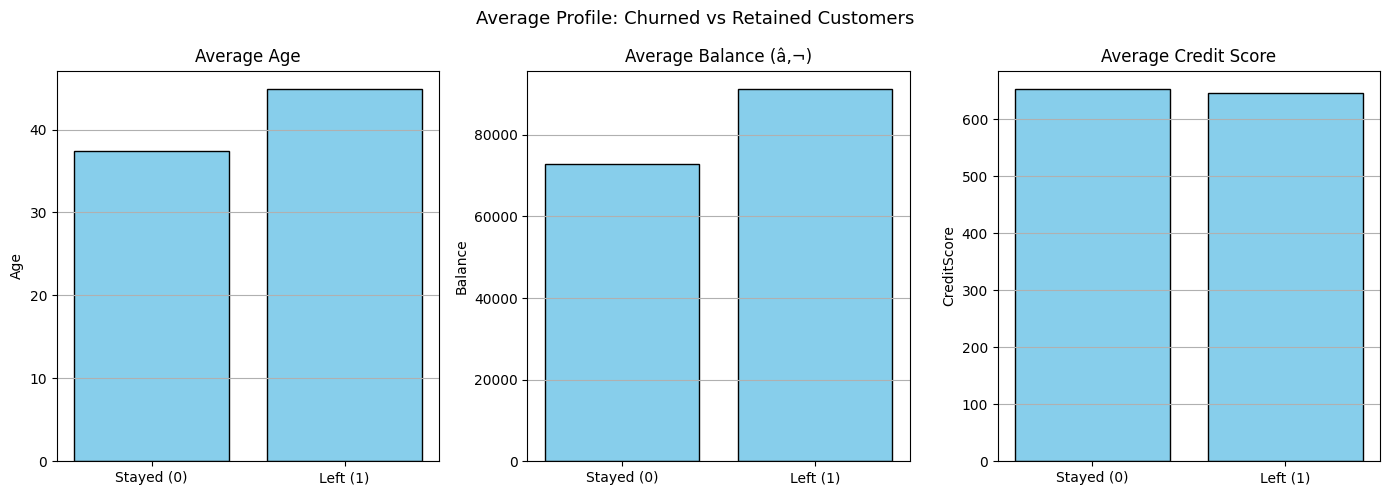

In [786]:
# Q18 â€” What is the average profile of a customer who left the bank?
profil = df.groupby('Exited')[['Age', 'Balance', 'CreditScore']].mean()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
cols = ['Age', 'Balance', 'CreditScore']
titles = ['Average Age', 'Average Balance (â‚¬)', 'Average Credit Score']

for ax, col, title in zip(axes, cols, titles):
    ax.bar(['Stayed (0)', 'Left (1)'], profil[col].values, color='skyblue', edgecolor='black')
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.grid(axis='y')

plt.suptitle('Average Profile: Churned vs Retained Customers', fontsize=13)
plt.tight_layout()
plt.show()

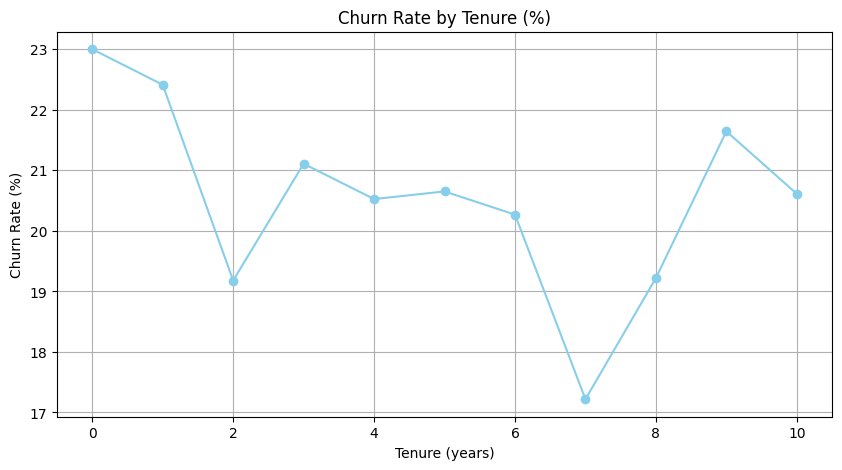

In [787]:
# Q19 â€” Do customers with a long tenure leave less?
churn_by_tenure = df.groupby('Tenure')['Exited'].mean() * 100

plt.figure(figsize=(10, 5))
plt.plot(churn_by_tenure.index, churn_by_tenure.values, marker='o', color='skyblue')
plt.title('Churn Rate by Tenure (%)')
plt.xlabel('Tenure (years)')
plt.ylabel('Churn Rate (%)')
plt.grid()
plt.show()

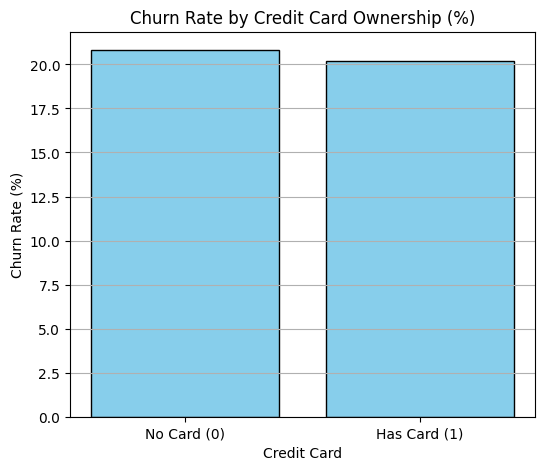

In [788]:
# Q20 â€” Do customers with a credit card stay longer?
churn_by_card = df.groupby('HasCrCard')['Exited'].mean() * 100

plt.figure(figsize=(6, 5))
plt.bar(['No Card (0)', 'Has Card (1)'], churn_by_card.values, color='skyblue', edgecolor='black')
plt.title('Churn Rate by Credit Card Ownership (%)')
plt.xlabel('Credit Card')
plt.ylabel('Churn Rate (%)')
plt.grid(axis='y')
plt.show()

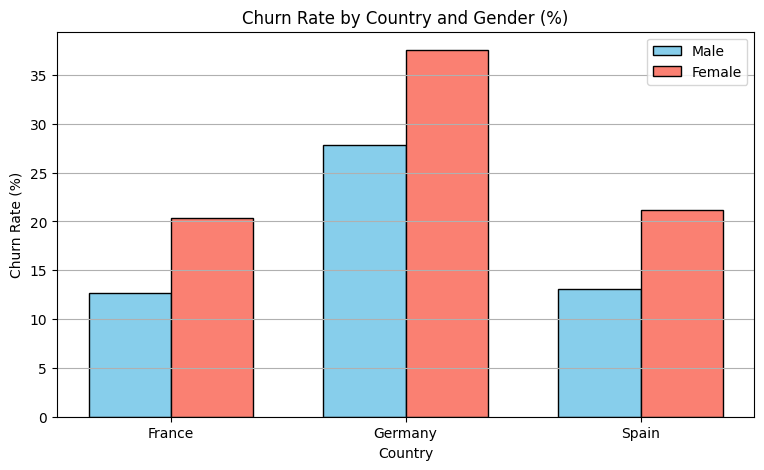

In [789]:
# Q21 â€” Is there an interaction between country and gender in the churn rate?
pivot = df.groupby(['Geography', 'Gender'])['Exited'].mean().unstack() * 100

x = range(len(pivot.index))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar([i - width/2 for i in x], pivot['Male'], width=width, label='Male', color='skyblue', edgecolor='black')
plt.bar([i + width/2 for i in x], pivot['Female'], width=width, label='Female', color='salmon', edgecolor='black')
plt.xticks(list(x), pivot.index)
plt.title('Churn Rate by Country and Gender (%)')
plt.xlabel('Country')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.grid(axis='y')
plt.show()

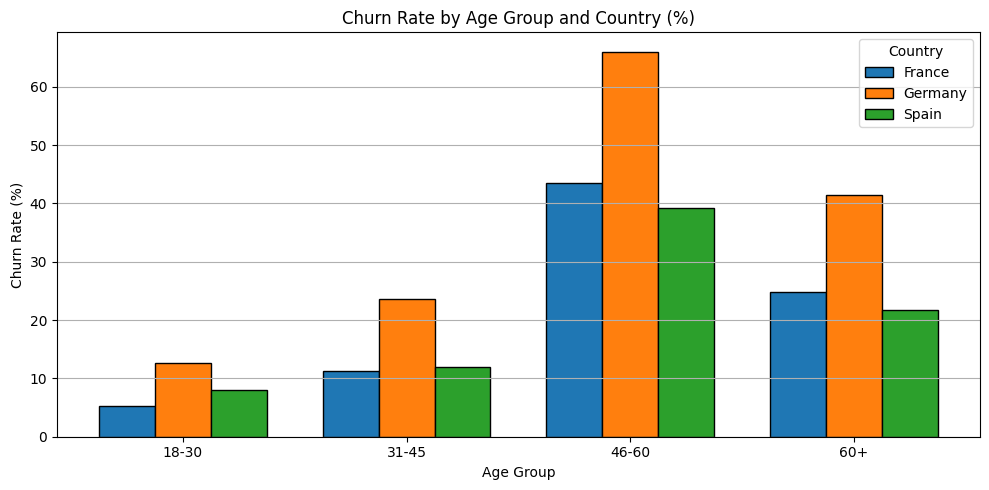

In [790]:
# Q22 â€” Which age Ã— geography segment has the highest churn risk?
bins = [18, 30, 45, 60, 100]
labels = ['18-30', '31-45', '46-60', '60+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

pivot = df.groupby(['AgeGroup', 'Geography'], observed=True)['Exited'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(pivot.index))
width = 0.25

for i, country in enumerate(pivot.columns):
    ax.bar([j + i * width for j in x], pivot[country], width=width, label=country, edgecolor='black')

ax.set_xticks([j + width for j in x])
ax.set_xticklabels(pivot.index.astype(str))
ax.set_title('Churn Rate by Age Group and Country (%)')
ax.set_xlabel('Age Group')
ax.set_ylabel('Churn Rate (%)')
ax.legend(title='Country')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

In [791]:
df = df.drop('AgeGroup', axis=1)

In [792]:
df.dtypes

CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

# Part 5 : Models Ai


### Helper Function : evaluate_classifier

Reusable function for each model: displays Accuracy, F1 Score, Classification Report, Confusion Matrix, and ROC Curve.

In [793]:

def evaluate_classifier(name, model, X_test_data, y_test_data):
    """
    Print metrics + classification report, then plot confusion matrix and ROC curve.
    """
    
    y_pred = model.predict(X_test_data)
    y_proba = model.predict_proba(X_test_data)[:, 1]
    
    print(f"=== {name} ===")
    print(f"Accuracy : {accuracy_score(y_test_data, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_test_data, y_pred):.4f}")
    print('\nClassification Report:')
    print(classification_report(y_test_data, y_pred, target_names=['No Disease', 'Disease']))
    
    # Confusion Matrix + ROC side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test_data, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'], ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title(f'{name} - Confusion Matrix')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test_data, y_proba)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{name} - ROC Curve')
    axes[1].legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()
    
    return y_pred, y_proba

---

### Model 1 : Logistic Regression


In [794]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

=== Logistic Regression ===
Accuracy : 0.8186
F1 Score : 0.8064

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.86      0.83      1633
     Disease       0.84      0.78      0.81      1553

    accuracy                           0.82      3186
   macro avg       0.82      0.82      0.82      3186
weighted avg       0.82      0.82      0.82      3186



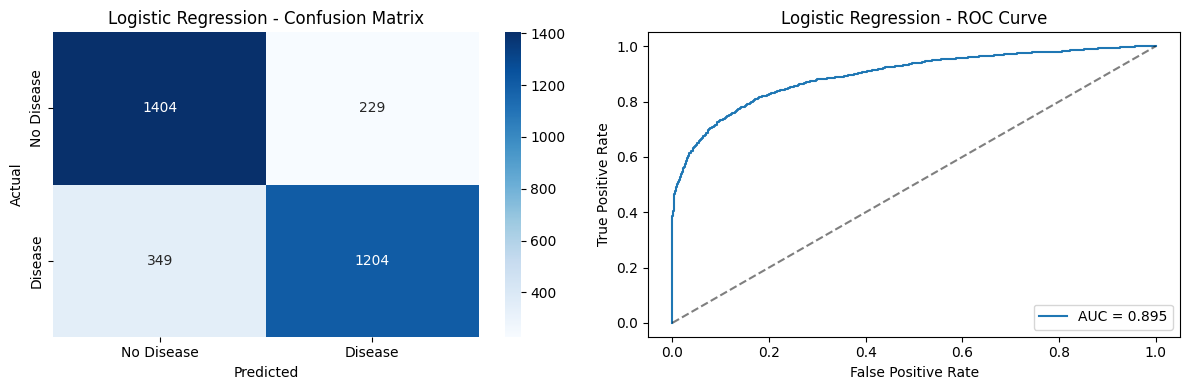

In [795]:
y_pred_lr, y_proba_lr = evaluate_classifier('Logistic Regression', logreg, X_test_scaled, y_test)

---

### Model 2 : K-Nearest Neighbors (KNN)

**Principle:** For each customer, finds the K nearest neighbors and votes by majority.

**Parameters:**
- `n_neighbors=5`: uses the 5 most similar customers to make a decision

In [796]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


=== KNN ===
Accuracy : 0.8519
F1 Score : 0.8446

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.84      0.88      0.86      1633
     Disease       0.86      0.83      0.84      1553

    accuracy                           0.85      3186
   macro avg       0.85      0.85      0.85      3186
weighted avg       0.85      0.85      0.85      3186



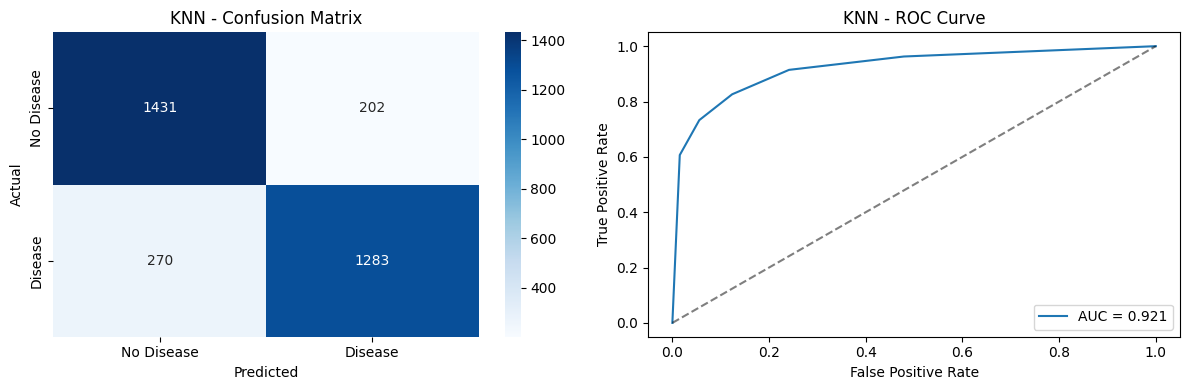

In [797]:
y_pred_knn,y_proba_knn=evaluate_classifier('KNN',knn,X_test_scaled,y_test)

---

### Model 3 : Decision Tree

**Principle:** Creates a decision tree by asking questions about the features (e.g., Age > 40? Balance > 100K?).

**Parameters:**
- `class_weight='balanced'`: compensates for class imbalance
- `random_state=42`: reproducible results

In [798]:
from sklearn.tree import DecisionTreeClassifier

# Training
dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt.fit(X_train_scaled,y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

=== Decision Tree ===
Accuracy : 0.8465
F1 Score : 0.8469

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.87      0.82      0.85      1633
     Disease       0.82      0.87      0.85      1553

    accuracy                           0.85      3186
   macro avg       0.85      0.85      0.85      3186
weighted avg       0.85      0.85      0.85      3186



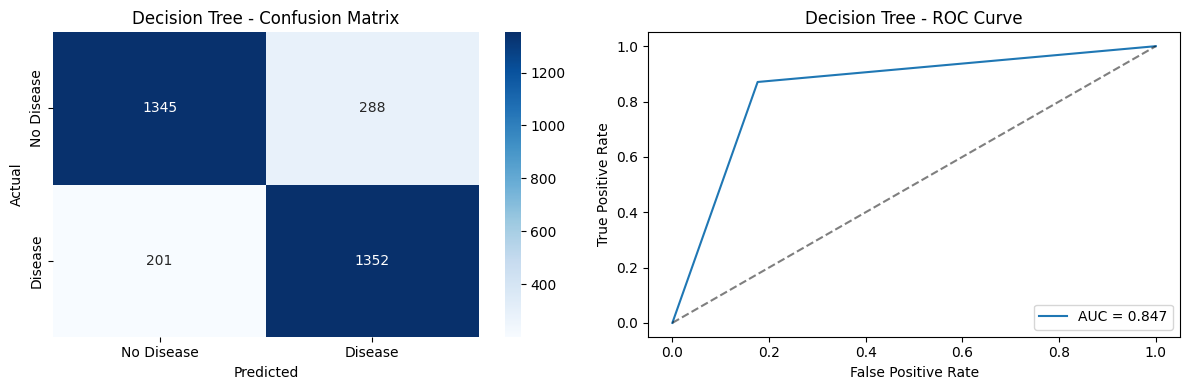

In [799]:
# Evaluation
y_pred_dt,y_proba_dt=evaluate_classifier('Decision Tree',dt,X_test_scaled,y_test)

---

### Model 4 : Random Forest

**Principle:** Builds 100 different decision trees and combines their votes (bagging). More robust than a single tree.

**Parameters:**
- `n_estimators=100`: 100 trees in the forest
- `class_weight='balanced'`: compensates for class imbalance
- `random_state=42`: reproducible results

In [800]:
from sklearn.ensemble import RandomForestClassifier

# Training
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced', min_samples_leaf=2, max_depth=14, n_jobs=-1)
rf.fit(X_train_scaled,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

=== Random Forest ===
Accuracy : 0.8920
F1 Score : 0.8882

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.89      0.90      0.90      1633
     Disease       0.90      0.88      0.89      1553

    accuracy                           0.89      3186
   macro avg       0.89      0.89      0.89      3186
weighted avg       0.89      0.89      0.89      3186



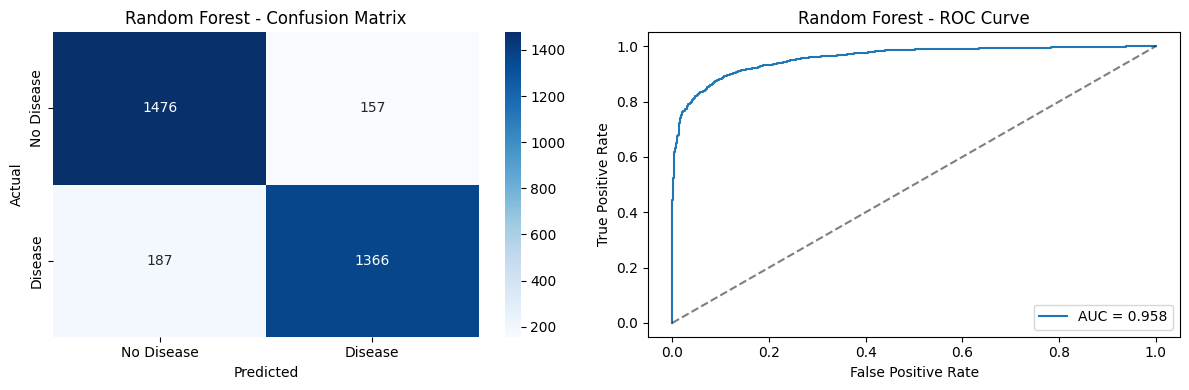

In [801]:
# Evaluation
y_pred_rf,y_proba_rf=evaluate_classifier('Random Forest',rf,X_test_scaled,y_test)

---

### Model 5 : Support Vector Machine (SVC)

**Principle:** Finds the boundary (hyperplane) that best separates customers who leave from those who stay, by maximizing the margin.

**Parameters:**
- `kernel='linear'`: linear separation boundary
- `probability=True`: required to compute the ROC curve

In [802]:
from sklearn.svm import SVC

svc = SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42)
svc.fit(X_train_scaled, y_train)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


=== Support Vector Machine (SVC) ===
Accuracy : 0.8186
F1 Score : 0.8062

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.86      0.83      1633
     Disease       0.84      0.77      0.81      1553

    accuracy                           0.82      3186
   macro avg       0.82      0.82      0.82      3186
weighted avg       0.82      0.82      0.82      3186



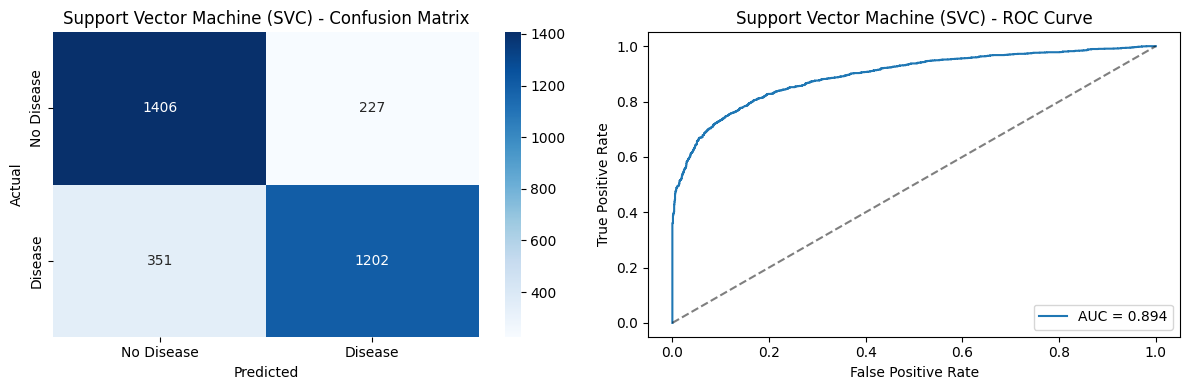

In [803]:
y_pred_svc, y_proba_svc = evaluate_classifier('Support Vector Machine (SVC)', svc, X_test_scaled, y_test)

---

### Model 7 : LightGBM

**Principle:** Another gradient boosting library (by Microsoft) that uses histogram-based learning â€” faster and often more accurate than XGBoost on tabular data.

**Parameters:**
- `n_estimators=300`, `learning_rate=0.05`: same boosting setup as XGBoost
- `num_leaves=63`: controls model complexity (default 31 â€” we allow more leaves for this dataset)

In [804]:
import lightgbm as lgb

lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    class_weight='balanced',
    random_state=42
)
lgbm.fit(X_train_scaled, y_train)

[LightGBM] [Info] Number of positive: 6410, number of negative: 6330
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0,003438 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1208
[LightGBM] [Info] Number of data points in the train set: 12740, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0,500000 -> initscore=-0,000000
[LightGBM] [Info] Start training from score -0,000000


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


=== LightGBM ===
Accuracy : 0.9043
F1 Score : 0.9003

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.90      0.92      0.91      1633
     Disease       0.91      0.89      0.90      1553

    accuracy                           0.90      3186
   macro avg       0.90      0.90      0.90      3186
weighted avg       0.90      0.90      0.90      3186



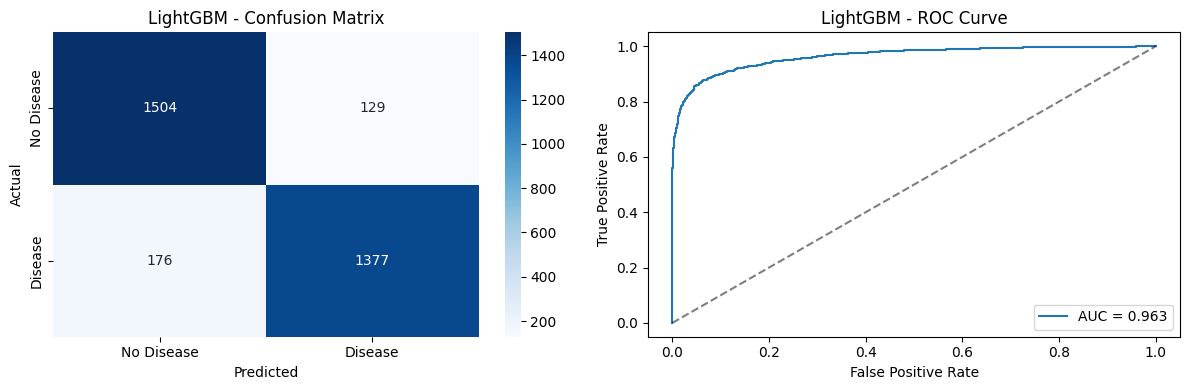

In [805]:
y_pred_lgbm, y_proba_lgbm = evaluate_classifier('LightGBM', lgbm, X_test_scaled, y_test)

---

### Model 6 : XGBoost

**Principle:** Gradient boosting â€” builds trees sequentially, each correcting the errors of the previous one. Usually outperforms Random Forest.

**Parameters:**
- `n_estimators=300`: 300 boosting rounds
- `learning_rate=0.05`: shrinks each tree's contribution to prevent overfitting
- `max_depth=5`, `subsample=0.8`, `colsample_bytree=0.8`: regularisation to reduce overfitting

In [806]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_scaled, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

=== XGBoost ===
Accuracy : 0.8958
F1 Score : 0.8910

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.88      0.92      0.90      1633
     Disease       0.91      0.87      0.89      1553

    accuracy                           0.90      3186
   macro avg       0.90      0.90      0.90      3186
weighted avg       0.90      0.90      0.90      3186



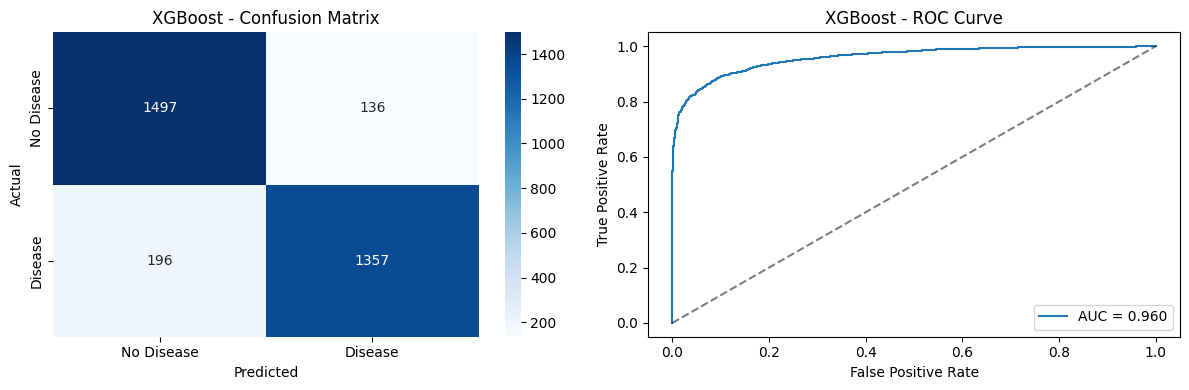

In [807]:
y_pred_XGB, y_proba_XGB = evaluate_classifier('XGBoost', xgb, X_test_scaled, y_test)

In [808]:
# Model Comparison
models_list = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'SVC', 'XGBoost', 'LightGBM']

acc_scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_svc),
    accuracy_score(y_test, y_pred_XGB),
    accuracy_score(y_test, y_pred_lgbm),
]

f1_scores = [
    f1_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_knn),
    f1_score(y_test, y_pred_dt),
    f1_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_svc),
    f1_score(y_test, y_pred_XGB),
    f1_score(y_test, y_pred_lgbm),
]

comparison_df = pd.DataFrame({'Model': models_list, 'Accuracy': acc_scores, 'F1 Score': f1_scores})
comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print('Model Comparison:')
display(comparison_df)

Model Comparison:


,Model,Accuracy,F1 Score
0,LightGBM,0.904269,0.900294
1,XGBoost,0.895794,0.891005
2,Random Forest,0.892028,0.888166
3,KNN,0.851852,0.844635
4,Decision Tree,0.846516,0.846852
5,Logistic Regression,0.818581,0.806430
6,SVC,0.818581,0.806170


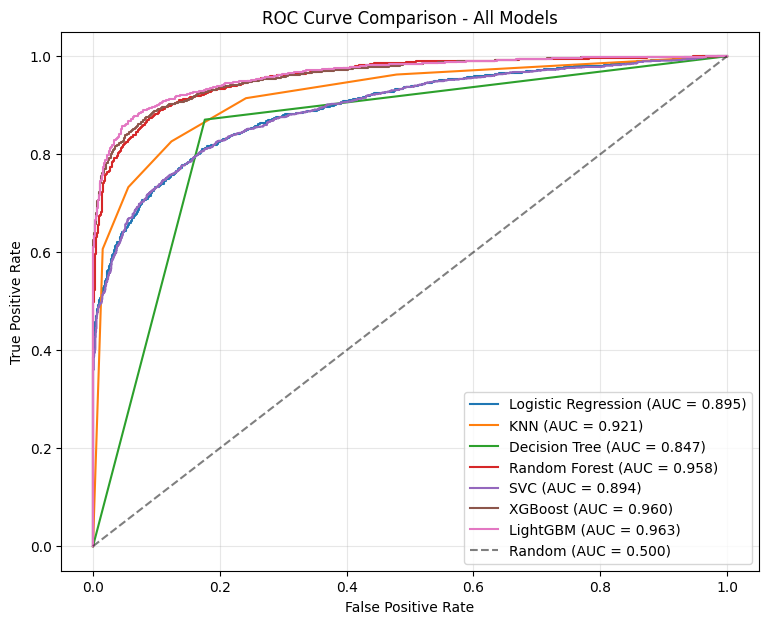

In [809]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(9, 7))

trained_models = {
    'Logistic Regression': logreg,
    'KNN':                 knn,
    'Decision Tree':       dt,
    'Random Forest':       rf,
    'SVC':                 svc,
    'XGBoost':             xgb,
    'LightGBM':            lgbm,
}

for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [810]:
import joblib

trained_models = {
    'Logistic Regression': logreg,
    'KNN':                 knn,
    'Decision Tree':       dt,
    'Random Forest':       rf,
    'SVC':                 svc,
    'XGBoost':             xgb,
    'LightGBM':            lgbm,
}

best_name = comparison_df.loc[comparison_df['F1 Score'].idxmax(), 'Model']
best_model = trained_models[best_name]
best_f1    = comparison_df['F1 Score'].max()
best_acc   = comparison_df.loc[comparison_df['F1 Score'].idxmax(), 'Accuracy']

print(f"Best model  : {best_name}")
print(f"F1 Score    : {best_f1:.4f}")
print(f"Accuracy    : {best_acc:.4f}")

joblib.dump(best_model, 'best_model_classifier.pkl')
joblib.dump(scaler,     'scaler.pkl')

print("\nSaved files:")
print("  best_model_classifier.pkl")
print("  scaler.pkl")

Best model  : LightGBM
F1 Score    : 0.9003
Accuracy    : 0.9043

Saved files:
  best_model_classifier.pkl
  scaler.pkl


In [811]:
best_model_row = comparison_df.loc[comparison_df['F1 Score'].idxmax()]
best_model_row

Model       LightGBM
Accuracy    0.904269
F1 Score    0.900294
Name: 0, dtype: object

---

# Part 6 : Cross-Validation

We apply **Stratified 5-Fold Cross-Validation** to all 7 models using the full training set.  
This gives a more reliable performance estimate than a single train/test split by evaluating each model on 5 different data splits.

- **Accuracy** : overall correctness  
- **F1 Score** : harmonic mean of precision and recall (best for imbalanced classes)  
- **ROC-AUC** : area under the ROC curve  

Results are shown as **mean ± std** across the 5 folds.

In [812]:
from sklearn.model_selection import cross_validate, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# Stratified 5-Fold: preserves class ratio in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_models = {
    'Logistic Regression': logreg,
    'KNN':                 knn,
    'Decision Tree':       dt,
    'Random Forest':       rf,
    'SVC':                 svc,
    'XGBoost':             xgb,
    'LightGBM':            lgbm,
}

scoring = {'accuracy': 'accuracy', 'f1': 'f1', 'roc_auc': 'roc_auc'}

cv_results = {}
print(f"{'Model':<25} | {'Accuracy':^19} | {'F1 Score':^19} | {'ROC-AUC':^19}")
print('-' * 93)

for name, model in all_models.items():
    scores = cross_validate(model, X_train_scaled, y_train, cv=cv,
                            scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'Accuracy': scores['test_accuracy'],
        'F1 Score': scores['test_f1'],
        'ROC-AUC':  scores['test_roc_auc'],
    }
    acc = scores['test_accuracy']
    f1  = scores['test_f1']
    roc = scores['test_roc_auc']
    print(f"{name:<25} | {acc.mean():.4f} +/- {acc.std():.4f}  "
          f"| {f1.mean():.4f} +/- {f1.std():.4f}  "
          f"| {roc.mean():.4f} +/- {roc.std():.4f}")

# Summary DataFrame
cv_summary = pd.DataFrame({
    'Model':         list(cv_results.keys()),
    'Accuracy Mean': [cv_results[m]['Accuracy'].mean() for m in cv_results],
    'Accuracy Std':  [cv_results[m]['Accuracy'].std()  for m in cv_results],
    'F1 Mean':       [cv_results[m]['F1 Score'].mean() for m in cv_results],
    'F1 Std':        [cv_results[m]['F1 Score'].std()  for m in cv_results],
    'ROC-AUC Mean':  [cv_results[m]['ROC-AUC'].mean()  for m in cv_results],
    'ROC-AUC Std':   [cv_results[m]['ROC-AUC'].std()   for m in cv_results],
}).sort_values('F1 Mean', ascending=False).reset_index(drop=True)

display(cv_summary)

Model                     |      Accuracy       |      F1 Score       |       ROC-AUC      
---------------------------------------------------------------------------------------------


Logistic Regression       | 0.8238 +/- 0.0036  | 0.8188 +/- 0.0040  | 0.9018 +/- 0.0043
KNN                       | 0.8468 +/- 0.0103  | 0.8440 +/- 0.0104  | 0.9147 +/- 0.0071
Decision Tree             | 0.8307 +/- 0.0055  | 0.8335 +/- 0.0058  | 0.8306 +/- 0.0055
Random Forest             | 0.8857 +/- 0.0093  | 0.8843 +/- 0.0090  | 0.9509 +/- 0.0055
SVC                       | 0.8239 +/- 0.0037  | 0.8180 +/- 0.0041  | 0.9015 +/- 0.0041
XGBoost                   | 0.8874 +/- 0.0088  | 0.8856 +/- 0.0083  | 0.9526 +/- 0.0053
LightGBM                  | 0.8936 +/- 0.0093  | 0.8920 +/- 0.0095  | 0.9547 +/- 0.0057


,Model,Accuracy Mean,Accuracy Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std
0,LightGBM,0.893642,0.009317,0.891985,0.009450,0.954740,0.005724
1,XGBoost,0.887363,0.008751,0.885619,0.008259,0.952578,0.005291
2,Random Forest,0.885714,0.009282,0.884342,0.008984,0.950927,0.005547
3,KNN,0.846782,0.010278,0.844043,0.010364,0.914685,0.007113
4,Decision Tree,0.830691,0.005537,0.833456,0.005783,0.830619,0.005531
5,Logistic Regression,0.823783,0.003597,0.818814,0.003956,0.901758,0.004273
6,SVC,0.823940,0.003670,0.818005,0.004104,0.901454,0.004064


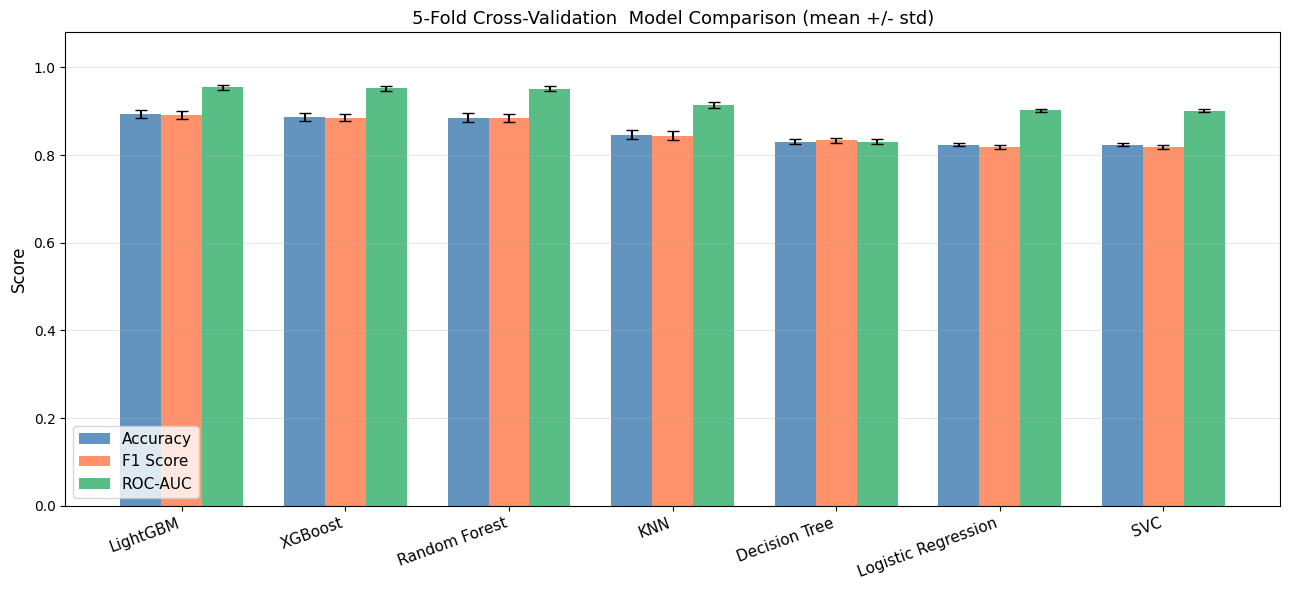

In [813]:
x     = np.arange(len(cv_summary))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(x - width, cv_summary['Accuracy Mean'], width,
       yerr=cv_summary['Accuracy Std'], capsize=4,
       label='Accuracy', color='steelblue', alpha=0.85)
ax.bar(x,          cv_summary['F1 Mean'],       width,
       yerr=cv_summary['F1 Std'],       capsize=4,
       label='F1 Score',  color='coral',      alpha=0.85)
ax.bar(x + width,  cv_summary['ROC-AUC Mean'],  width,
       yerr=cv_summary['ROC-AUC Std'],  capsize=4,
       label='ROC-AUC',   color='mediumseagreen', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(cv_summary['Model'], rotation=20, ha='right', fontsize=11)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('5-Fold Cross-Validation  Model Comparison (mean +/- std)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---

# Part 7 : Prediction on New Data

In [814]:
# Predicting on new data â€” raw input
new_data = {
    'CreditScore': 650,
    'Gender': 'Male',
    'Age': 35,
    'Tenure': 5,
    'Balance': 50000.0,
    'NumOfProducts': 2,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 60000.0,
    'Geography': 'France'  
}

new_df = pd.DataFrame([new_data])

# One-Hot Encoding using the same approach as training
new_df = pd.get_dummies(new_df, columns=['Geography', 'Gender'])

# Ensure all expected columns are present (add missing columns as 0)
expected_columns = X_train.columns

for col in expected_columns:
    if col not in new_df.columns:
        new_df[col] = 0

# Reorder columns to match the training order
new_df = new_df[expected_columns]

# Scale
new_df_scaled = scaler.transform(new_df)

display(new_df_scaled)

predicted_class = rf.predict(new_df_scaled)
predicted_proba = rf.predict_proba(new_df_scaled)

label = 'Churn' if predicted_class[0] == 1 else 'No Churn'

print(f"Predicted Class: {predicted_class[0]} ({label})")
print(f'Probability [No Churn, Churn]: {predicted_proba[0]}')

array([[ 0.01181735, -0.83789666, -0.59678634,  0.07034794, -0.52172313,
         1.02166384,  0.77621886,  1.31433152, -0.70654255,  1.25718514,
        -0.57432905, -0.46375548, -0.68465846, -0.03951841, -0.91167021]])

Predicted Class: 0 (No Churn)
Probability [No Churn, Churn]: [0.80324026 0.19675974]


---

# Part 8 : Save The Best Model

We automatically select the best model based on the **F1 Score** (most suitable for the churn problem), then save it with `joblib`.

- `best_model_classifier.pkl` â†’ the trained model
- `scaler.pkl` â†’ the StandardScaler (required for new data)

In [815]:
import joblib

# Automatically select the best model based on F1 Score
trained_models = {
    'Logistic Regression': logreg,
    'KNN':                 knn,
    'Decision Tree':       dt,
    'Random Forest':       rf,
    'SVC':                 svc,
}

best_name = comparison_df.loc[comparison_df['F1 Score'].idxmax(), 'Model']
trained_models = {
    'Logistic Regression': logreg,
    'KNN':                 knn,
    'Decision Tree':       dt,
    'Random Forest':       rf,
    'SVC':                 svc,
    'XGBoost':             xgb,
    'LightGBM':            lgbm,
}

best_model = trained_models[best_name]
best_f1    = comparison_df['F1 Score'].max()
best_acc   = comparison_df.loc[comparison_df['F1 Score'].idxmax(), 'Accuracy']

print(f"Best model  : {best_name}")
print(f"F1 Score    : {best_f1:.4f}")
print(f"Accuracy    : {best_acc:.4f}")

# Save
joblib.dump(best_model, 'best_model_classifier.pkl')
joblib.dump(scaler,     'scaler.pkl')

print("\nSaved files:")
print("  best_model_classifier.pkl")
print("  scaler.pkl")

Best model  : LightGBM
F1 Score    : 0.9003
Accuracy    : 0.9043

Saved files:
  best_model_classifier.pkl
  scaler.pkl


In [816]:
# Verification: load and test the saved model
loaded_model  = joblib.load('best_model_classifier.pkl')
loaded_scaler = joblib.load('scaler.pkl')

new_data = {
    'CreditScore': 650, 'Gender': 'Male', 'Age': 35, 'Tenure': 5,
    'Balance': 50000.0, 'NumOfProducts': 2, 'HasCrCard': 1,
    'IsActiveMember': 1, 'EstimatedSalary': 60000.0, 'Geography': 'France'
}

new_df = pd.DataFrame([new_data])
new_df = pd.get_dummies(new_df, columns=['Geography', 'Gender'])

for col in loaded_scaler.feature_names_in_:
    if col not in new_df.columns:
        new_df[col] = 0
new_df = new_df[loaded_scaler.feature_names_in_]

new_scaled      = loaded_scaler.transform(new_df)
predicted_class = loaded_model.predict(new_scaled)
predicted_proba = loaded_model.predict_proba(new_scaled)

label = 'Churn' if predicted_class[0] == 1 else 'No Churn'
print(f"Loaded model    : {best_name}")
print(f"Prediction      : {predicted_class[0]} ({label})")
print(f"Probabilities   : No Churn={predicted_proba[0][0]:.2f}  Churn={predicted_proba[0][1]:.2f}")

Loaded model    : LightGBM
Prediction      : 0 (No Churn)
Probabilities   : No Churn=0.93  Churn=0.07


---

# Part 9 : Deploying the Model " Streamlit Web App

The `app.py` file contains a complete web application built with **Streamlit**.

### App Features
- Interactive sidebar to input a customer's profile
- Gauge chart displaying churn risk in %
- Color-coded verdict: No Churn or  Churn
- Feature Importance chart from the Random Forest

### How to Launch the App

```bash
# 1. Install Streamlit (one time only)
pip install streamlit plotly

# 2. Launch the app (from the project folder)
streamlit run app.py
```

The app opens automatically at **http://localhost:8501**

In [817]:
import subprocess, sys

# Install dependencies if needed
subprocess.run([sys.executable, '-m', 'pip', 'install', 'streamlit', 'plotly', '-q'])

# Launch the app (runs in background â€” open http://localhost:8501)
subprocess.Popen([sys.executable, '-m', 'streamlit', 'run', 'app.py',
                  '--server.headless', 'true'])

print("App launched â†’ http://localhost:8501")

App launched â†’ http://localhost:8501
